# Autoresearch Experiment Analysis

Analysis of autonomous loss-search results from `results.tsv`.

The notebook assumes the current `loss_suitability`-only results schema.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    df = pd.read_csv("results.tsv", sep="\t")
except pd.errors.ParserError:
    # Fallback for rows where description contains extra tab characters.
    rows = []
    with open("results.tsv", "r", encoding="utf-8") as f:
        header = f.readline().rstrip("\n").split("\t")
        for line in f:
            parts = line.rstrip("\n").split("\t", 3)  # keep extra tabs in description
            if len(parts) < 4:
                parts += [""] * (4 - len(parts))
            rows.append(parts[:4])

    cols = header[:4] if len(header) >= 4 else ["commit", "loss_suitability", "status", "description"]
    df = pd.DataFrame(rows, columns=cols)

required_columns = ["commit", "loss_suitability", "status", "description"]
missing_columns = [name for name in required_columns if name not in df.columns]
if missing_columns:
    raise ValueError(
        f"results.tsv is missing required columns {missing_columns}; got {list(df.columns)}"
    )

metric_col = "loss_suitability"
metric_label = "Loss Suitability"
metric_short = "loss"

df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Primary metric: {metric_col} ({metric_label}, lower is better)")
df.head(10)

Total experiments: 58
Columns: ['commit', 'loss_suitability', 'status', 'description']
Primary metric: loss_suitability (Loss Suitability, lower is better)


,commit,loss_suitability,status,description
0,87f08fb,41.260345,KEEP,"baseline (symmetry_break=0, sorted_row_init, i..."
1,8886bd3,40.187836,KEEP,identity_init=False + per-sample epsilon
2,70813c9,45.290420,DISCARD,sorted_row full annealing (degraded perm-eq an...
3,ae48134,41.289879,DISCARD,"stronger annealing hurt opt-recovery, no conti..."
4,c6d8d85,37.976952,KEEP,sorted_row_init=False: huge padding+batch gain...
5,b874ffa,36.045973,KEEP,topk k=8: improved identity+symmetry+opt-recov...
6,71a9d5c,34.211980,KEEP,topk k=6: good K_max/identity/recovery balance
7,710132e,34.211997,DISCARD,symmetric trial T^T is no-op (T* already local...
8,5291a45,33.378647,KEEP,float32 cast fixes low-precision NaN (Test 12 ...
9,3ed332d,50.851630,DISCARD,symmetrized warm start broke solver (T0 too soft)


In [3]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    39
KEEP       19

Keep rate: 19/58 = 32.8%


In [4]:
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    score = row[metric_col]
    desc = row["description"]
    print(f"  #{i:3d}  {metric_col}={score:.6f}  {desc}")

KEPT experiments (19 total):

  #  0  loss_suitability=41.260345  baseline (symmetry_break=0, sorted_row_init, identity_init)
  #  1  loss_suitability=40.187836  identity_init=False + per-sample epsilon
  #  4  loss_suitability=37.976952  sorted_row_init=False: huge padding+batch gains offset by identity/opt-recovery regression
  #  5  loss_suitability=36.045973  topk k=8: improved identity+symmetry+opt-recovery but K_max tripled
  #  6  loss_suitability=34.211980  topk k=6: good K_max/identity/recovery balance
  #  8  loss_suitability=33.378647  float32 cast fixes low-precision NaN (Test 12 perfect)
  # 10  loss_suitability=32.766531  non-negativity clamp (Test 1 perfect)
  # 15  loss_suitability=30.175922  symmetric dual-direction solver: Test 3 perfect, net +2.6pts
  # 17  loss_suitability=29.080839  straight-through symmetric: Test3 perfect, batch-inv+opt-rec restored
  # 19  loss_suitability=28.920423  max_inner=30: batch-inv 40x better, K_max 3x worse, runtime near budget
  # 23 

## Metric Over Time

Track how the best kept score evolves over time. The running minimum shows the current frontier, and lower is always better.

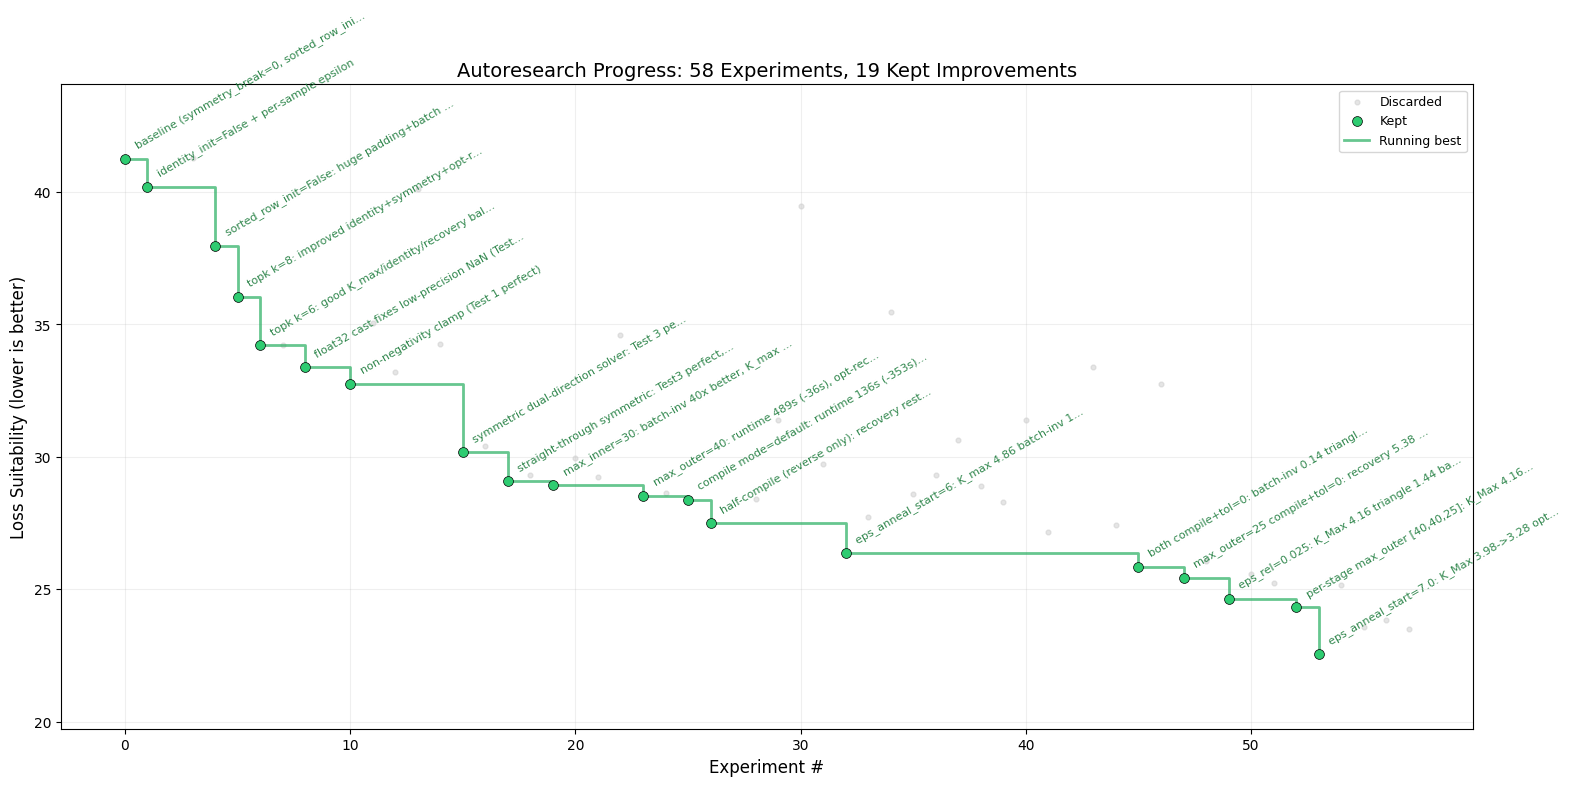

Saved to progress.png


In [5]:
fig, ax = plt.subplots(figsize=(16, 8))

valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_metric = valid.loc[0, metric_col]
window = max(1.0, abs(baseline_metric) * 0.25)
below = valid[valid[metric_col] <= baseline_metric + window]

disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc[metric_col],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v[metric_col],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_metric = valid.loc[kept_mask, metric_col]
running_min = kept_metric.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

for idx, score in zip(kept_idx, kept_metric):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, score),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel(f"{metric_label} (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

best_metric = kept_metric.min()
span = max(baseline_metric - best_metric, max(abs(baseline_metric) * 0.05, 1e-6))
margin = span * 0.15
ax.set_ylim(best_metric - margin, baseline_metric + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [6]:
kept = df[df["status"] == "KEEP"].copy()
baseline_metric = df.iloc[0][metric_col]
best_metric = kept[metric_col].min()
best_row = kept.loc[kept[metric_col].idxmin()]

improvement = baseline_metric - best_metric
improvement_pct = (improvement / baseline_metric * 100.0) if abs(baseline_metric) > 1e-12 else np.nan

print(f"Baseline {metric_col}: {baseline_metric:.6f}")
print(f"Best {metric_col}:     {best_metric:.6f}")
print(f"Total improvement:    {improvement:.6f} ({improvement_pct:.2f}%)")
print(f"Best experiment:      {best_row['description']}")
print()

print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for _, row in kept_sorted.iterrows():
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: {metric_short}={row[metric_col]:.6f}  {desc}")

Baseline loss_suitability: 41.260345
Best loss_suitability:     22.540600
Total improvement:    18.719745 (45.37%)
Best experiment:      eps_anneal_start=7.0: K_Max 3.98->3.28 opt-rec 5.22->4.11 batch-inv maintained

Cumulative effort per improvement:
  Experiment #  0: loss=41.260345  baseline (symmetry_break=0, sorted_row_init, identity_init)
  Experiment #  1: loss=40.187836  identity_init=False + per-sample epsilon
  Experiment #  4: loss=37.976952  sorted_row_init=False: huge padding+batch gains offset by identity/opt-recovery regression
  Experiment #  5: loss=36.045973  topk k=8: improved identity+symmetry+opt-recovery but K_max tripled
  Experiment #  6: loss=34.211980  topk k=6: good K_max/identity/recovery balance
  Experiment #  8: loss=33.378647  float32 cast fixes low-precision NaN (Test 12 perfect)
  Experiment # 10: loss=32.766531  non-negativity clamp (Test 1 perfect)
  Experiment # 15: loss=30.175922  symmetric dual-direction solver: Test 3 perfect, net +2.6pts
  Exper

## Top Hits (Kept Experiments by Improvement)

In [7]:
kept = df[df["status"] == "KEEP"].copy()
kept["prev_metric"] = kept[metric_col].shift(1)
kept["delta"] = kept["prev_metric"] - kept[metric_col]

hits = kept.iloc[1:].copy()
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>10}  {'Metric':>12}  Description")
print("-" * 90)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+10.6f}  {row[metric_col]:12.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+10.6f}  {'':>12}  TOTAL improvement over baseline")

Rank       Delta        Metric  Description
------------------------------------------------------------------------------------------
   1   +2.590609     30.175922  symmetric dual-direction solver: Test 3 perfect, net +2.6pts
   2   +2.210884     37.976952  sorted_row_init=False: huge padding+batch gains offset by identity/opt-recovery regression
   3   +1.930979     36.045973  topk k=8: improved identity+symmetry+opt-recovery but K_max tripled
   4   +1.833993     34.211980  topk k=6: good K_max/identity/recovery balance
   5   +1.772374     22.540600  eps_anneal_start=7.0: K_Max 3.98->3.28 opt-rec 5.22->4.11 batch-inv maintained
   6   +1.130011     26.352376  eps_anneal_start=6: K_max 4.86 batch-inv 1.88 triangle 1.94
   7   +1.095083     29.080839  straight-through symmetric: Test3 perfect, batch-inv+opt-rec restored
   8   +1.072509     40.187836  identity_init=False + per-sample epsilon
   9   +0.893768     27.482387  half-compile (reverse only): recovery restored, runtime 316s